In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.cuda.amp import autocast, GradScaler
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import optuna
from pathlib import Path
import os
import json
from tqdm import tqdm
import warnings
from PIL import Image
import math
from scipy import ndimage
import random
import time

warnings.filterwarnings('ignore')

# ============ GPU OPTIMIZATION SETUP ============

# Enable CUDA optimizations for maximum performance
torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed
torch.backends.cuda.matmul.allow_tf32 = True  # Enable TF32 on Ampere GPUs
torch.backends.cudnn.allow_tf32 = True

# Output directory for all artifacts
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set device and seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
world_size = torch.cuda.device_count()
print(f"Using device: {device}, GPUs available: {world_size}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB per GPU")

def set_seed(seed=42):
    """Set seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    # Note: We disable deterministic for speed but keep seed for reproducibility where possible

set_seed(42)

# Data paths
DATA_PATHS = {
    'train_x': '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x',
    'train_y': '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/y',
    'val_x': '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x',
    'val_y': '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/y',
    'test_x': '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/test/x'
}

# ============ OPTIMIZED BATCH SIZE FINDER ============

def find_optimal_batch_size(model, input_size=(3, 512, 512), max_batch_size=128):
    """Automatically find the optimal batch size for maximum GPU utilization"""
    model.eval()
    optimal_batch_size = 1
    
    print("Finding optimal batch size...")
    
    for batch_size in [2, 4, 8, 16, 32, 64, 128, 256]:
        if batch_size > max_batch_size:
            break
            
        try:
            # Clear cache
            torch.cuda.empty_cache()
            
            # Create dummy input
            dummy_input = torch.randn(batch_size, *input_size).to(device)
            dummy_target = torch.randint(0, 3, (batch_size, input_size[1], input_size[2])).to(device)
            
            # Test forward pass
            with autocast():
                output = model(dummy_input)
                if isinstance(output, tuple):
                    output = output[0]
                loss = F.cross_entropy(output, dummy_target)
            
            # Test backward pass
            loss.backward()
            
            optimal_batch_size = batch_size
            print(f"Batch size {batch_size} works - GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB")
            
            del dummy_input, dummy_target, output, loss
            torch.cuda.empty_cache()
            
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"Batch size {batch_size} failed - Out of memory")
                break
            else:
                raise e
    
    model.train()
    print(f"Optimal batch size: {optimal_batch_size}")
    return optimal_batch_size

# ============ CHECKPOINT SAVING FUNCTIONS ============

def save_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, phase, filename_suffix=""):
    """Save comprehensive checkpoint with AMP scaler state"""
    # Handle DataParallel/DDP models
    model_state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model_state,
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'scaler_state_dict': scaler.state_dict() if scaler else None,
        'best_val_score': best_val_score,
        'history': history,
        'hyperparams': hyperparams,
        'phase': phase,
        'device_count': torch.cuda.device_count() if torch.cuda.is_available() else 0,
        'model_architecture': 'EfficientMylomaNetWithDeepSupervision'
    }
    
    checkpoint_path = os.path.join(OUTPUT_DIR, f'checkpoint_epoch_{epoch}_{phase}{filename_suffix}.pth')
    torch.save(checkpoint, checkpoint_path)
    
    # Also save history separately
    history_path = os.path.join(OUTPUT_DIR, f'training_history_epoch_{epoch}.pkl')
    import pickle
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    
    print(f"Checkpoint saved: {checkpoint_path}")
    return checkpoint_path

def save_final_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, phase):
    """Save final checkpoint with special naming"""
    checkpoint_path = save_checkpoint(
        model, optimizer, scaler, epoch, history, best_val_score, 
        hyperparams, phase, filename_suffix="_FINAL"
    )
    
    # Also save as 'latest_checkpoint.pth' for easy resuming
    model_state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
    latest_path = os.path.join(OUTPUT_DIR, 'latest_checkpoint.pth')
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model_state,
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'scaler_state_dict': scaler.state_dict() if scaler else None,
        'best_val_score': best_val_score,
        'history': history,
        'hyperparams': hyperparams,
        'phase': phase,
        'device_count': torch.cuda.device_count() if torch.cuda.is_available() else 0,
        'model_architecture': 'EfficientMylomaNetWithDeepSupervision'
    }
    torch.save(checkpoint, latest_path)
    
    print(f"Final checkpoint saved: {checkpoint_path}")
    print(f"Latest checkpoint saved: {latest_path}")
    return checkpoint_path

def load_checkpoint(checkpoint_path, model, optimizer=None, scaler=None):
    """Load checkpoint and return training state"""
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Load model state (handle DataParallel)
    if hasattr(model, 'module'):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load optimizer state if provided
    if optimizer and checkpoint.get('optimizer_state_dict'):
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Load scaler state if provided
    if scaler and checkpoint.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    return (
        checkpoint['epoch'],
        checkpoint['best_val_score'],
        checkpoint['history'],
        checkpoint['phase'],
        checkpoint.get('hyperparams', {})
    )

# ============ ENHANCED LOSS FUNCTIONS ============

class FocalTverskyLoss(nn.Module):
    """Advanced Focal Tversky Loss for medical segmentation"""
    def __init__(self, alpha=0.7, beta=0.3, gamma=1.33, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        
        if class_weights is None:
            class_weights = torch.tensor([0.1, 1.0, 1.0])
        self.register_buffer('class_weights', class_weights)
    
    def forward(self, pred, target):
        pred = F.softmax(pred, dim=1)
        target = target.long()
        
        tversky_losses = []
        
        for c in range(1, pred.shape[1]):
            pred_c = pred[:, c]
            target_c = (target == c).float()
            
            tp = (pred_c * target_c).sum()
            fp = (pred_c * (1 - target_c)).sum()
            fn = ((1 - pred_c) * target_c).sum()
            
            tversky = tp / (tp + self.alpha * fp + self.beta * fn + 1e-8)
            focal_tversky = (1 - tversky) ** self.gamma
            tversky_losses.append(focal_tversky)
        
        return sum(tversky_losses) / len(tversky_losses) if tversky_losses else torch.tensor(0.0, device=pred.device)

class ActiveBoundaryLoss(nn.Module):
    """Active Boundary Loss for improved boundary accuracy"""
    def __init__(self, theta0=3, theta=5):
        super().__init__()
        self.theta0 = theta0
        self.theta = theta
    
    def extract_boundary(self, mask):
        """Extract boundary using morphological operations"""
        if len(mask.shape) == 4:
            boundaries = []
            for i in range(mask.shape[0]):
                mask_np = mask[i].cpu().numpy().astype(np.uint8)
                if len(mask_np.shape) == 3:
                    mask_np = mask_np[0] if mask_np.shape[0] == 1 else np.argmax(mask_np, axis=0)
                
                kernel = np.ones((3, 3), np.uint8)
                boundary = cv2.morphologyEx(mask_np, cv2.MORPH_GRADIENT, kernel)
                boundaries.append(torch.from_numpy(boundary).to(mask.device))
            return torch.stack(boundaries)
        else:
            mask_np = mask.cpu().numpy().astype(np.uint8)
            if len(mask_np.shape) == 3:
                mask_np = mask_np[0] if mask_np.shape[0] == 1 else np.argmax(mask_np, axis=0)
            
            kernel = np.ones((3, 3), np.uint8)
            boundary = cv2.morphologyEx(mask_np, cv2.MORPH_GRADIENT, kernel)
            return torch.from_numpy(boundary).to(mask.device)
    
    def forward(self, pred, target, epoch):
        boundary_weight = min(1.0, epoch / self.theta0) if epoch < self.theta else 1.0
        
        target_boundary = self.extract_boundary(target.unsqueeze(1) if len(target.shape) == 3 else target)
        pred_argmax = torch.argmax(pred, dim=1, keepdim=True)
        pred_boundary = self.extract_boundary(pred_argmax)
        
        boundary_loss = F.mse_loss(pred_boundary.float(), target_boundary.float())
        
        return boundary_weight * boundary_loss

class EnhancedCombinedLoss(nn.Module):
    """Enhanced combined loss with Focal Tversky and Active Boundary Loss"""
    def __init__(self, class_weights=None, focal_weight=0.4, boundary_weight=0.2, ce_weight=0.4):
        super().__init__()
        self.focal_weight = focal_weight
        self.boundary_weight = boundary_weight
        self.ce_weight = ce_weight
        
        if class_weights is None:
            class_weights = torch.tensor([0.1, 1.0, 1.0])
        self.register_buffer('class_weights', class_weights)
        
        self.focal_tversky = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33)
        self.boundary_loss = ActiveBoundaryLoss(theta0=3, theta=5)
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        
        self.current_epoch = 0
    
    def set_epoch(self, epoch):
        self.current_epoch = epoch
    
    def forward(self, pred, target):
        target = target.long()
        
        ce_loss = self.ce_loss(pred, target)
        focal_loss = self.focal_tversky(pred, target)
        boundary_loss = self.boundary_loss(pred, target, self.current_epoch)
        
        total_loss = (self.ce_weight * ce_loss + 
                     self.focal_weight * focal_loss + 
                     self.boundary_weight * boundary_loss)
        
        return total_loss

# ============ ENHANCED MODEL ARCHITECTURE ============

class DepthwiseSeparableConv(nn.Module):
    """GPU-optimized depthwise separable convolution"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, 
                                 stride, padding, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU6(inplace=True)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class LightweightAttention(nn.Module):
    """Lightweight channel and spatial attention"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, 7, padding=3),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca
        
        # Spatial attention
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        spatial_input = torch.cat([avg_pool, max_pool], dim=1)
        sa = self.spatial_attention(spatial_input)
        x = x * sa
        
        return x

class EfficientMylomaNetWithDeepSupervision(nn.Module):
    """Enhanced EfficientMylomaNet with Deep Supervision and GPU optimizations"""
    def __init__(self, num_classes=3):
        super().__init__()
        
        # Encoder
        self.encoder1 = nn.Sequential(
            DepthwiseSeparableConv(3, 32),
            DepthwiseSeparableConv(32, 64)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.encoder2 = nn.Sequential(
            DepthwiseSeparableConv(64, 128),
            DepthwiseSeparableConv(128, 128),
            LightweightAttention(128)
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.encoder3 = nn.Sequential(
            DepthwiseSeparableConv(128, 256),
            DepthwiseSeparableConv(256, 256),
            LightweightAttention(256)
        )
        self.pool3 = nn.MaxPool2d(2)
        
        self.encoder4 = nn.Sequential(
            DepthwiseSeparableConv(256, 512),
            DepthwiseSeparableConv(512, 512),
            LightweightAttention(512)
        )
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            DepthwiseSeparableConv(512, 1024),
            DepthwiseSeparableConv(1024, 512),
            LightweightAttention(512)
        )
        
        # Decoder
        self.upconv4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder4 = nn.Sequential(
            DepthwiseSeparableConv(768, 256),
            DepthwiseSeparableConv(256, 256)
        )
        
        self.upconv3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder3 = nn.Sequential(
            DepthwiseSeparableConv(384, 128),
            DepthwiseSeparableConv(128, 128)
        )
        
        self.upconv2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder2 = nn.Sequential(
            DepthwiseSeparableConv(192, 64),
            DepthwiseSeparableConv(64, 64)
        )
        
        self.upconv1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.decoder1 = nn.Sequential(
            DepthwiseSeparableConv(96, 32),
            DepthwiseSeparableConv(32, 32)
        )
        
        # Main output
        self.final_conv = nn.Conv2d(32, num_classes, 1)
        
        # Deep supervision heads
        self.aux_head1 = nn.Conv2d(256, num_classes, 1)
        self.aux_head2 = nn.Conv2d(128, num_classes, 1)
        self.aux_head3 = nn.Conv2d(64, num_classes, 1)
        
    def forward(self, x):
        input_size = x.shape[2:]
        
        # Encoder
        enc1 = self.encoder1(x)
        pool1 = self.pool1(enc1)
        
        enc2 = self.encoder2(pool1)
        pool2 = self.pool2(enc2)
        
        enc3 = self.encoder3(pool2)
        pool3 = self.pool3(enc3)
        
        enc4 = self.encoder4(pool3)
        pool4 = self.pool4(enc4)
        
        # Bottleneck
        bottleneck = self.bottleneck(pool4)
        
        # Decoder
        up4 = self.upconv4(bottleneck)
        dec4 = self.decoder4(torch.cat([up4, enc4], dim=1))
        
        up3 = self.upconv3(dec4)
        dec3 = self.decoder3(torch.cat([up3, enc3], dim=1))
        
        up2 = self.upconv2(dec3)
        dec2 = self.decoder2(torch.cat([up2, enc2], dim=1))
        
        up1 = self.upconv1(dec2)
        dec1 = self.decoder1(torch.cat([up1, enc1], dim=1))
        
        # Main output
        output = self.final_conv(dec1)
        
        if self.training:
            # Deep supervision outputs
            aux1 = F.interpolate(self.aux_head1(dec4), size=input_size, mode='bilinear', align_corners=False)
            aux2 = F.interpolate(self.aux_head2(dec3), size=input_size, mode='bilinear', align_corners=False)
            aux3 = F.interpolate(self.aux_head3(dec2), size=input_size, mode='bilinear', align_corners=False)
            
            return output, aux1, aux2, aux3
        
        return output

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ============ OPTIMIZED DATA LOADING ============

class ClassSpecificAugmentation:
    """Class-specific augmentation for better class balance"""
    def __init__(self):
        self.foreground_transforms = A.Compose([
            A.ElasticTransform(alpha=100, sigma=10, p=0.8),
            A.GridDistortion(num_steps=5, distort_limit=0.5, p=0.8),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.8),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.6),
            A.GaussianBlur(blur_limit=3, p=0.4)
        ], is_check_shapes=False)
        
        self.background_transforms = A.Compose([
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
            A.RandomGamma(gamma_limit=(80, 120), p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
        ], is_check_shapes=False)
    
    def __call__(self, image, mask):
        foreground_ratio = np.sum(mask > 0) / mask.size
        
        if foreground_ratio > 0.05:
            return self.foreground_transforms(image=image, mask=mask)
        else:
            return self.background_transforms(image=image, mask=mask)

def get_enhanced_train_transforms(image_size=512):
    """Enhanced training transforms"""
    base_transforms = A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.6),
        A.OneOf([
            A.OpticalDistortion(distort_limit=0.1, shift_limit=0.1, p=1.0),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        ], p=0.5),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=1.0),
            A.RandomGamma(gamma_limit=(80, 120), p=1.0),
        ], p=0.7),
        A.OneOf([
            A.GaussianBlur(blur_limit=3, p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
            A.MedianBlur(blur_limit=3, p=1.0),
        ], p=0.3),
        A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], is_check_shapes=False)
    
    return base_transforms

def get_val_transforms(image_size=512):
    """Validation transforms"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], is_check_shapes=False)

# ============ TEST-TIME AUGMENTATION ============

class TestTimeAugmentation:
    """Advanced Test-Time Augmentation with AMP support"""
    def __init__(self, model, device):
        self.model = model
        self.device = device
        
    def __call__(self, image):
        self.model.eval()
        predictions = []
        
        transforms = [
            lambda x: x,  # Original
            lambda x: torch.rot90(x, 1, [2, 3]),
            lambda x: torch.rot90(x, 2, [2, 3]),
            lambda x: torch.rot90(x, 3, [2, 3]),
            lambda x: torch.flip(x, [2]),
            lambda x: torch.flip(x, [3]),
            lambda x: torch.flip(torch.rot90(x, 1, [2, 3]), [2]),
            lambda x: torch.flip(torch.rot90(x, 1, [2, 3]), [3])
        ]
        
        inv_transforms = [
            lambda x: x,  # Original
            lambda x: torch.rot90(x, 3, [2, 3]),
            lambda x: torch.rot90(x, 2, [2, 3]),
            lambda x: torch.rot90(x, 1, [2, 3]),
            lambda x: torch.flip(x, [2]),
            lambda x: torch.flip(x, [3]),
            lambda x: torch.flip(torch.rot90(x, 3, [2, 3]), [2]),
            lambda x: torch.flip(torch.rot90(x, 3, [2, 3]), [3])
        ]
        
        with torch.no_grad():
            for transform, inv_transform in zip(transforms, inv_transforms):
                aug_image = transform(image)
                
                with autocast():
                    pred = self.model(aug_image)
                    if isinstance(pred, tuple):
                        pred = pred[0]
                
                pred = inv_transform(pred)
                predictions.append(pred)
        
        return torch.mean(torch.stack(predictions), dim=0)

# ============ ENHANCED DATASET WITH OPTIMIZED LOADING ============

def combine_masks_fixed(mask_files, target_size=(512, 512)):
    """Enhanced mask combination"""
    combined_mask = np.zeros(target_size, dtype=np.int64)
    
    for i, mask_file in enumerate(mask_files):
        try:
            mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            
            if mask is None:
                mask = np.array(Image.open(mask_file).convert('L'))
            
            if mask is not None:
                mask = cv2.resize(mask, target_size)
                
                if mask.max() <= 40:
                    mask_binary = (mask > 0).astype(np.int64)
                else:
                    mask_binary = (mask > 127).astype(np.int64)
                
                combined_mask[mask_binary == 1] = 1
                
        except Exception as e:
            print(f"Error processing mask {mask_file}: {e}")
    
    return combined_mask

class OptimizedSegPCDataset(Dataset):
    """Optimized dataset with fast loading and memory efficiency"""
    def __init__(self, image_dir, mask_dir=None, transform=None, is_test=False, 
                 target_size=(512, 512), use_class_specific_aug=False, training_mode=True):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir) if mask_dir else None
        self.transform = transform
        self.is_test = is_test
        self.target_size = target_size
        self.use_class_specific_aug = use_class_specific_aug
        self.training_mode = training_mode
        
        if self.use_class_specific_aug:
            self.class_specific_aug = ClassSpecificAugmentation()
        
        self.image_files = sorted(list(self.image_dir.glob("*.bmp")))
        
        if not self.is_test and self.mask_dir:
            self.image_mask_mapping = self._create_image_mask_mapping()
            print(f"Created mapping for {len(self.image_mask_mapping)} images")
    
    def set_training_mode(self, training_mode):
        self.training_mode = training_mode
    
    def _create_image_mask_mapping(self):
        mask_files = list(self.mask_dir.glob("*.bmp"))
        mapping = {}
        
        for img_file in self.image_files:
            img_name = img_file.stem
            corresponding_masks = []
            
            for mask_file in mask_files:
                mask_name = mask_file.stem
                if mask_name.startswith(img_name + "_"):
                    corresponding_masks.append(mask_file)
            
            if corresponding_masks:
                mapping[img_file] = corresponding_masks
        
        return mapping
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image
        image_path = self.image_files[idx]
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.target_size)
        
        if self.is_test:
            if self.transform:
                transformed = self.transform(image=image)
                image = transformed['image']
            return image, str(image_path.name)
        
        # Handle masks
        if image_path in self.image_mask_mapping:
            mask_files = self.image_mask_mapping[image_path]
            combined_mask = combine_masks_fixed(mask_files, self.target_size)
        else:
            combined_mask = np.zeros(self.target_size, dtype=np.int64)
        
        if self.use_class_specific_aug and self.training_mode:
            try:
                aug_result = self.class_specific_aug(image, combined_mask.astype(np.uint8))
                image = aug_result['image']
                combined_mask = aug_result['mask'].astype(np.int64)
            except:
                pass
        
        # Apply main transforms
        if self.transform:
            try:
                transformed = self.transform(image=image, mask=combined_mask.astype(np.uint8))
                image = transformed['image']
                mask = transformed['mask'].long()
            except:
                image_transform = A.Compose([
                    A.Resize(self.target_size[0], self.target_size[1]),
                    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                    ToTensorV2()
                ])
                transformed = image_transform(image=image)
                image = transformed['image']
                mask = torch.from_numpy(combined_mask).long()
        else:
            mask = torch.from_numpy(combined_mask).long()
        
        return image, mask

# ============ GPU-OPTIMIZED DATA LOADING ============

def create_optimized_dataloader(dataset, batch_size, shuffle=True, num_workers=None, pin_memory=True):
    """Create optimized DataLoader for maximum GPU utilization"""
    if num_workers is None:
        # Use optimal number of workers based on CPU cores and GPU count
        num_workers = min(os.cpu_count(), 8 * torch.cuda.device_count()) if torch.cuda.is_available() else 4
    
    # Enable memory pinning for faster GPU transfers
    return DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True if num_workers > 0 else False,  # Keep workers alive
        prefetch_factor=2 if num_workers > 0 else 2,  # Prefetch batches
        drop_last=True if shuffle else False  # Consistent batch sizes for better GPU utilization
    )

# ============ ADVANCED TRAINING STRATEGIES ============

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, min_lr=1e-6):
    """Cosine learning rate schedule with warmup"""
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        cosine_factor = max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
        return max(min_lr / optimizer.param_groups[0]['lr'], cosine_factor)
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class MultiMetricEarlyStopping:
    """Multi-metric early stopping"""
    def __init__(self, patience=25, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = 0
        self.early_stop = False
        
    def __call__(self, val_metrics):
        current_score = (0.4 * val_metrics.get('mean_F1', 0) + 
                        0.3 * val_metrics.get('mean_IoU', 0) + 
                        0.3 * val_metrics.get('mean_Dice', 0))
        
        if current_score > self.best_score + self.min_delta:
            self.best_score = current_score
            self.counter = 0
            self.early_stop = False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop

# ============ ENHANCED METRICS ============

def calculate_enhanced_metrics(pred, target, num_classes=3):
    """Enhanced metrics calculation"""
    pred = torch.argmax(pred, dim=1)
    target = target.long()
    
    metrics = {}
    valid_classes = []
    
    for c in range(num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        
        if target_c.sum() == 0:
            metrics[f'class_{c}'] = {
                'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0
            }
            continue
            
        valid_classes.append(c)
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum() - intersection
        
        iou = (intersection + 1e-8) / (union + 1e-8)
        dice = (2 * intersection + 1e-8) / (pred_c.sum() + target_c.sum() + 1e-8)
        
        pred_np = pred_c.cpu().numpy().flatten()
        target_np = target_c.cpu().numpy().flatten()
        
        if len(np.unique(target_np)) > 1 and len(np.unique(pred_np)) > 1:
            precision = precision_score(target_np, pred_np, zero_division=0)
            recall = recall_score(target_np, pred_np, zero_division=0)
            f1 = f1_score(target_np, pred_np, zero_division=0)
        else:
            precision = recall = f1 = 0.0
        
        metrics[f'class_{c}'] = {
            'IoU': iou.item(),
            'Dice': dice.item(),
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
    
    # Calculate mean metrics
    mean_metrics = {}
    foreground_classes = [c for c in valid_classes if c > 0]
    
    if foreground_classes:
        for metric_name in ['IoU', 'Dice', 'Precision', 'Recall', 'F1']:
            mean_metrics[f'mean_{metric_name}'] = np.mean([
                metrics[f'class_{c}'][metric_name] for c in foreground_classes
            ])
            mean_metrics[f'overall_{metric_name}'] = np.mean([
                metrics[f'class_{c}'][metric_name] for c in valid_classes
            ])
    else:
        for metric_name in ['IoU', 'Dice', 'Precision', 'Recall', 'F1']:
            mean_metrics[f'mean_{metric_name}'] = 0.0
            mean_metrics[f'overall_{metric_name}'] = 0.0
    
    return metrics, mean_metrics

# ============ OPTIMIZED TRAINING FUNCTIONS WITH AMP ============

def train_epoch_optimized(model, dataloader, criterion, optimizer, scaler, device, epoch, accumulation_steps=1):
    """Optimized training with AMP, gradient accumulation, and deep supervision"""
    model.train()
    total_loss = 0
    all_metrics = []
    successful_batches = 0
    
    if hasattr(criterion, 'set_epoch'):
        criterion.set_epoch(epoch)
    
    # Memory monitoring
    if epoch % 10 == 0:
        print(f"GPU Memory before epoch: {torch.cuda.memory_allocated()/1e9:.2f}GB")
    
    optimizer.zero_grad()
    
    for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc="Training")):
        try:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True).long()
            
            # Mixed precision forward pass
            with autocast():
                outputs = model(images)
                if isinstance(outputs, tuple):  # Deep supervision
                    main_output, aux1, aux2, aux3 = outputs
                    
                    main_loss = criterion(main_output, masks)
                    aux_loss1 = criterion(aux1, masks) * 0.4
                    aux_loss2 = criterion(aux2, masks) * 0.3
                    aux_loss3 = criterion(aux3, masks) * 0.2
                    
                    loss = main_loss + aux_loss1 + aux_loss2 + aux_loss3
                    outputs = main_output
                else:
                    loss = criterion(outputs, masks)
                
                # Scale loss for gradient accumulation
                loss = loss / accumulation_steps
            
            # Backward pass with gradient scaling
            scaler.scale(loss).backward()
            
            # Gradient accumulation
            if (batch_idx + 1) % accumulation_steps == 0:
                # Gradient clipping
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                # Optimizer step
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            total_loss += loss.item() * accumulation_steps
            successful_batches += 1
            
            # Calculate metrics (less frequently to save time)
            if batch_idx % 5 == 0:
                with torch.no_grad():
                    _, mean_metrics = calculate_enhanced_metrics(outputs.detach(), masks.detach())
                    all_metrics.append(mean_metrics)
            
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"OOM in batch {batch_idx}, clearing cache...")
                torch.cuda.empty_cache()
                continue
            else:
                print(f"Error in training batch {batch_idx}: {e}")
                continue
    
    # Average metrics
    if all_metrics:
        avg_metrics = {}
        for key in all_metrics[0].keys():
            avg_metrics[key] = np.mean([m[key] for m in all_metrics])
    else:
        avg_metrics = {f'mean_{metric}': 0.0 for metric in ['IoU', 'Dice', 'F1', 'Precision', 'Recall']}
    
    avg_loss = total_loss / successful_batches if successful_batches > 0 else 0.0
    return avg_loss, avg_metrics

def validate_epoch_optimized(model, dataloader, criterion, device, use_tta=False):
    """Optimized validation with AMP and optional TTA"""
    model.eval()
    total_loss = 0
    all_metrics = []
    successful_batches = 0
    
    tta = TestTimeAugmentation(model, device) if use_tta else None
    
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc="Validation")):
            try:
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True).long()
                
                # Mixed precision inference
                if use_tta and tta:
                    outputs = tta(images)
                else:
                    with autocast():
                        outputs = model(images)
                        if isinstance(outputs, tuple):
                            outputs = outputs[0]
                
                with autocast():
                    loss = criterion(outputs, masks)
                
                total_loss += loss.item()
                successful_batches += 1
                
                _, mean_metrics = calculate_enhanced_metrics(outputs, masks)
                all_metrics.append(mean_metrics)
                
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"OOM in validation batch {batch_idx}, clearing cache...")
                    torch.cuda.empty_cache()
                    continue
                else:
                    print(f"Error in validation batch {batch_idx}: {e}")
                    continue
    
    # Average metrics
    if all_metrics:
        avg_metrics = {}
        for key in all_metrics[0].keys():
            avg_metrics[key] = np.mean([m[key] for m in all_metrics])
    else:
        avg_metrics = {f'mean_{metric}': 0.0 for metric in ['IoU', 'Dice', 'F1', 'Precision', 'Recall']}
    
    avg_loss = total_loss / successful_batches if successful_batches > 0 else 0.0
    return avg_loss, avg_metrics

# ============ ULTRA-OPTIMIZED PROGRESSIVE TRAINING PIPELINE ============

def ultra_optimized_progressive_training(hyperparams):
    """Ultra-optimized progressive training with all GPU optimizations"""
    print("=== ULTRA-OPTIMIZED PROGRESSIVE TRAINING WITH ALL GPU OPTIMIZATIONS ===")
    print(f"GPUs Available: {world_size}")
    
    # Create enhanced model
    model = EfficientMylomaNetWithDeepSupervision()
    
    # Multi-GPU optimization
    if world_size > 1:
        print(f"Using DataParallel on {world_size} GPUs for maximum speed!")
        model = nn.DataParallel(model, device_ids=list(range(world_size)))
    
    model = model.to(device)
    print(f"Model parameters: {count_parameters(model):,}")
    
    # Find optimal batch size
    base_batch_size = find_optimal_batch_size(model, max_batch_size=hyperparams.get('max_batch_size', 128))
    
    # Multiply by number of GPUs for effective batch size
    effective_batch_size = base_batch_size * world_size
    print(f"Effective batch size: {effective_batch_size} ({base_batch_size} per GPU)")
    
    # Enhanced loss function
    criterion = EnhancedCombinedLoss().to(device)
    
    # Initialize AMP scaler
    scaler = GradScaler()
    
    # Training history
    history = {key: [] for key in [
        'train_loss', 'val_loss', 'train_iou', 'val_iou', 'train_dice', 'val_dice',
        'train_f1', 'val_f1', 'train_precision', 'val_precision', 'train_recall', 'val_recall'
    ]}
    
    best_val_score = 0
    best_model_state = None
    
    # Calculate gradient accumulation steps for very large effective batch sizes
    accumulation_steps = max(1, effective_batch_size // (base_batch_size * world_size))
    print(f"Gradient accumulation steps: {accumulation_steps}")
    
    # ============ PHASE 1: Initial Training ============
    print("\nPhase 1: Initial Training with Maximum GPU Utilization (Epochs 1-80)")
    
    # Optimized transforms
    train_transform = get_enhanced_train_transforms(hyperparams['image_size'])
    val_transform = get_val_transforms(hyperparams['image_size'])
    
    # Optimized datasets
    train_dataset = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['train_x'],
        mask_dir=DATA_PATHS['train_y'],
        transform=train_transform,
        target_size=(hyperparams['image_size'], hyperparams['image_size']),
        use_class_specific_aug=False,
        training_mode=True
    )
    
    val_dataset = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['val_x'],
        mask_dir=DATA_PATHS['val_y'],
        transform=val_transform,
        target_size=(hyperparams['image_size'], hyperparams['image_size']),
        training_mode=False
    )
    
    # Ultra-optimized data loaders
    train_loader = create_optimized_dataloader(
        train_dataset, 
        batch_size=base_batch_size, 
        shuffle=True,
        num_workers=min(16, os.cpu_count()),  # Maximum workers
        pin_memory=True
    )
    
    val_loader = create_optimized_dataloader(
        val_dataset, 
        batch_size=base_batch_size * 2,  # Larger batch for validation
        shuffle=False,
        num_workers=min(8, os.cpu_count()),
        pin_memory=True
    )
    
    print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
    
    # Calculate steps for scheduling
    total_steps = 80 * len(train_loader)
    warmup_steps = int(0.1 * total_steps)
    
    # Phase 1 optimizer with optimized settings
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=hyperparams['lr'] * world_size,  # Scale LR with number of GPUs
        weight_decay=hyperparams['weight_decay'],
        eps=1e-8,  # Stable for mixed precision
        betas=(0.9, 0.999)
    )
    
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    early_stopping = MultiMetricEarlyStopping(patience=20)
    
    # Phase 1 training loop with all optimizations
    phase1_start_time = time.time()
    
    for epoch in range(80):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/80")
        
        # Training with all optimizations
        train_loss, train_metrics = train_epoch_optimized(
            model, train_loader, criterion, optimizer, scaler, device, epoch, accumulation_steps
        )
        
        # Validation
        val_loss, val_metrics = validate_epoch_optimized(model, val_loader, criterion, device)
        
        scheduler.step()
        
        # Performance monitoring
        epoch_time = time.time() - epoch_start_time
        samples_per_sec = len(train_dataset) / epoch_time
        gpu_utilization = torch.cuda.utilization() if hasattr(torch.cuda, 'utilization') else 'N/A'
        
        print(f"Epoch time: {epoch_time:.2f}s, Samples/sec: {samples_per_sec:.1f}, GPU util: {gpu_utilization}%")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics.get('mean_IoU', 0.0))
        history['val_iou'].append(val_metrics.get('mean_IoU', 0.0))
        history['train_dice'].append(train_metrics.get('mean_Dice', 0.0))
        history['val_dice'].append(val_metrics.get('mean_Dice', 0.0))
        history['train_f1'].append(train_metrics.get('mean_F1', 0.0))
        history['val_f1'].append(val_metrics.get('mean_F1', 0.0))
        history['train_precision'].append(train_metrics.get('mean_Precision', 0.0))
        history['val_precision'].append(val_metrics.get('mean_Precision', 0.0))
        history['train_recall'].append(train_metrics.get('mean_Recall', 0.0))
        history['val_recall'].append(val_metrics.get('mean_Recall', 0.0))
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train IoU: {train_metrics.get('mean_IoU', 0.0):.4f}, Val IoU: {val_metrics.get('mean_IoU', 0.0):.4f}")
        print(f"Train F1: {train_metrics.get('mean_F1', 0.0):.4f}, Val F1: {val_metrics.get('mean_F1', 0.0):.4f}")
        
        # Track best model
        current_score = (0.4 * val_metrics.get('mean_F1', 0) + 
                        0.3 * val_metrics.get('mean_IoU', 0) + 
                        0.3 * val_metrics.get('mean_Dice', 0))
        
        if current_score > best_val_score:
            best_val_score = current_score
            best_model_state = model.state_dict().copy()
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_score': best_val_score,
                'hyperparams': hyperparams,
                'history': history
            }, os.path.join(OUTPUT_DIR, 'best_optimized_model.pth'))
            print(f"New best model (Score: {best_val_score:.4f})")
        
        # Save checkpoint every 50 epochs
        if (epoch + 1) % 50 == 0:
            save_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase1")
            
            # Memory cleanup
            torch.cuda.empty_cache()
        
        if early_stopping(val_metrics):
            print("Early stopping triggered in Phase 1")
            break
    
    phase1_time = time.time() - phase1_start_time
    print(f"Phase 1 completed in {phase1_time/60:.1f} minutes")
    
    # Save final checkpoint for Phase 1
    save_final_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase1")
    
    # ============ PHASE 2: Enhanced Training ============
    print("\nPhase 2: Enhanced Training with Class-Specific Augmentation (Epochs 81-160)")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    # Phase 2 optimizer (lower learning rate)
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=hyperparams['lr'] * world_size * 0.3, 
        weight_decay=hyperparams['weight_decay'] * 0.5
    )
    
    # Enhanced dataset with class-specific augmentation
    train_dataset_enhanced = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['train_x'],
        mask_dir=DATA_PATHS['train_y'],
        transform=train_transform,
        target_size=(hyperparams['image_size'], hyperparams['image_size']),
        use_class_specific_aug=True,
        training_mode=True
    )
    
    train_loader_enhanced = create_optimized_dataloader(
        train_dataset_enhanced, 
        batch_size=base_batch_size,
        shuffle=True,
        num_workers=min(16, os.cpu_count()),
        pin_memory=True
    )
    
    early_stopping = MultiMetricEarlyStopping(patience=25)
    phase2_start_time = time.time()
    
    # Phase 2 training loop
    for epoch in range(80, 160):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/160")
        
        train_loss, train_metrics = train_epoch_optimized(
            model, train_loader_enhanced, criterion, optimizer, scaler, device, epoch, accumulation_steps
        )
        val_loss, val_metrics = validate_epoch_optimized(model, val_loader, criterion, device)
        
        # Performance monitoring
        epoch_time = time.time() - epoch_start_time
        samples_per_sec = len(train_dataset_enhanced) / epoch_time
        print(f"Epoch time: {epoch_time:.2f}s, Samples/sec: {samples_per_sec:.1f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics.get('mean_IoU', 0.0))
        history['val_iou'].append(val_metrics.get('mean_IoU', 0.0))
        history['train_dice'].append(train_metrics.get('mean_Dice', 0.0))
        history['val_dice'].append(val_metrics.get('mean_Dice', 0.0))
        history['train_f1'].append(train_metrics.get('mean_F1', 0.0))
        history['val_f1'].append(val_metrics.get('mean_F1', 0.0))
        history['train_precision'].append(train_metrics.get('mean_Precision', 0.0))
        history['val_precision'].append(val_metrics.get('mean_Precision', 0.0))
        history['train_recall'].append(train_metrics.get('mean_Recall', 0.0))
        history['val_recall'].append(val_metrics.get('mean_Recall', 0.0))
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train IoU: {train_metrics.get('mean_IoU', 0.0):.4f}, Val IoU: {val_metrics.get('mean_IoU', 0.0):.4f}")
        print(f"Train F1: {train_metrics.get('mean_F1', 0.0):.4f}, Val F1: {val_metrics.get('mean_F1', 0.0):.4f}")
        
        # Track best model
        current_score = (0.4 * val_metrics.get('mean_F1', 0) + 
                        0.3 * val_metrics.get('mean_IoU', 0) + 
                        0.3 * val_metrics.get('mean_Dice', 0))
        
        if current_score > best_val_score:
            best_val_score = current_score
            best_model_state = model.state_dict().copy()
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_score': best_val_score,
                'hyperparams': hyperparams,
                'history': history
            }, os.path.join(OUTPUT_DIR, 'best_optimized_model.pth'))
            print(f"New best model (Score: {best_val_score:.4f})")
        
        # Save checkpoint every 50 epochs
        if (epoch + 1) % 50 == 0:
            save_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase2")
            torch.cuda.empty_cache()
        
        if early_stopping(val_metrics):
            print("Early stopping triggered in Phase 2")
            break
    
    phase2_time = time.time() - phase2_start_time
    print(f"Phase 2 completed in {phase2_time/60:.1f} minutes")
    
    save_final_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase2")
    
    # ============ PHASE 3: Fine-tuning with TTA ============
    print("\nPhase 3: Fine-tuning with Test-Time Augmentation (Epochs 161-200)")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    # Phase 3 optimizer (very low learning rate)
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=hyperparams['lr'] * world_size * 0.1, 
        weight_decay=hyperparams['weight_decay'] * 0.1
    )
    
    phase3_start_time = time.time()
    
    # Phase 3 training loop with TTA validation
    for epoch in range(160, 200):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/200")
        
        train_loss, train_metrics = train_epoch_optimized(
            model, train_loader_enhanced, criterion, optimizer, scaler, device, epoch, accumulation_steps
        )
        val_loss, val_metrics = validate_epoch_optimized(model, val_loader, criterion, device, use_tta=True)
        
        # Performance monitoring
        epoch_time = time.time() - epoch_start_time
        samples_per_sec = len(train_dataset_enhanced) / epoch_time
        print(f"Epoch time: {epoch_time:.2f}s, Samples/sec: {samples_per_sec:.1f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics.get('mean_IoU', 0.0))
        history['val_iou'].append(val_metrics.get('mean_IoU', 0.0))
        history['train_dice'].append(train_metrics.get('mean_Dice', 0.0))
        history['val_dice'].append(val_metrics.get('mean_Dice', 0.0))
        history['train_f1'].append(train_metrics.get('mean_F1', 0.0))
        history['val_f1'].append(val_metrics.get('mean_F1', 0.0))
        history['train_precision'].append(train_metrics.get('mean_Precision', 0.0))
        history['val_precision'].append(val_metrics.get('mean_Precision', 0.0))
        history['train_recall'].append(train_metrics.get('mean_Recall', 0.0))
        history['val_recall'].append(val_metrics.get('mean_Recall', 0.0))
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train IoU: {train_metrics.get('mean_IoU', 0.0):.4f}, Val IoU (TTA): {val_metrics.get('mean_IoU', 0.0):.4f}")
        print(f"Train F1: {train_metrics.get('mean_F1', 0.0):.4f}, Val F1 (TTA): {val_metrics.get('mean_F1', 0.0):.4f}")
        
        # Track best model
        current_score = (0.4 * val_metrics.get('mean_F1', 0) + 
                        0.3 * val_metrics.get('mean_IoU', 0) + 
                        0.3 * val_metrics.get('mean_Dice', 0))
        
        if current_score > best_val_score:
            best_val_score = current_score
            best_model_state = model.state_dict().copy()
            print(f"New best model with TTA (Score: {best_val_score:.4f})")
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_score': best_val_score,
                'hyperparams': hyperparams,
                'history': history
            }, os.path.join(OUTPUT_DIR, 'best_optimized_model.pth'))
        
        # Save checkpoint every 50 epochs
        if (epoch + 1) % 50 == 0:
            save_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase3")
            torch.cuda.empty_cache()
        
        # Check if target achieved
        if (val_metrics.get('mean_F1', 0) >= 0.90 and 
            val_metrics.get('mean_IoU', 0) >= 0.75 and 
            val_metrics.get('mean_Dice', 0) >= 0.90):
            print("TARGET METRICS ACHIEVED!")
            break
    
    phase3_time = time.time() - phase3_start_time
    print(f"Phase 3 completed in {phase3_time/60:.1f} minutes")
    
    save_final_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, "phase3_FINAL")
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    total_time = (phase1_time + phase2_time + phase3_time) / 60
    print(f"Total training time: {total_time:.1f} minutes")
    print(f"Average speed: {len(train_dataset) * (epoch + 1) / (total_time * 60):.1f} samples/second")
    
    return model, history, best_val_score

# ============ PLOTTING AND EVALUATION ============

def plot_enhanced_training_history(history):
    """Plot enhanced training curves"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss', color='red', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # IoU
    axes[0, 1].plot(epochs, history['train_iou'], label='Train IoU', color='blue', linewidth=2)
    axes[0, 1].plot(epochs, history['val_iou'], label='Val IoU', color='red', linewidth=2)
    axes[0, 1].axhline(y=0.75, color='green', linestyle='--', alpha=0.7, label='Target (75%)')
    axes[0, 1].set_title('IoU Score (Foreground)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('IoU')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Dice
    axes[0, 2].plot(epochs, history['train_dice'], label='Train Dice', color='blue', linewidth=2)
    axes[0, 2].plot(epochs, history['val_dice'], label='Val Dice', color='red', linewidth=2)
    axes[0, 2].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='Target (90%)')
    axes[0, 2].set_title('Dice Score (Foreground)', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Dice')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # F1
    axes[1, 0].plot(epochs, history['train_f1'], label='Train F1', color='blue', linewidth=2)
    axes[1, 0].plot(epochs, history['val_f1'], label='Val F1', color='red', linewidth=2)
    axes[1, 0].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='Target (90%)')
    axes[1, 0].set_title('F1 Score (Foreground)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 1].plot(epochs, history['train_precision'], label='Train Precision', color='blue', linewidth=2)
    axes[1, 1].plot(epochs, history['val_precision'], label='Val Precision', color='red', linewidth=2)
    axes[1, 1].set_title('Precision (Foreground)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 2].plot(epochs, history['train_recall'], label='Train Recall', color='blue', linewidth=2)
    axes[1, 2].plot(epochs, history['val_recall'], label='Val Recall', color='red', linewidth=2)
    axes[1, 2].set_title('Recall (Foreground)', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Recall')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add phase markers
    phase1_end = 80
    phase2_end = 160
    
    for ax in axes.flat:
        if len(epochs) > phase1_end:
            ax.axvline(x=phase1_end, color='orange', linestyle=':', alpha=0.8, linewidth=2)
        if len(epochs) > phase2_end:
            ax.axvline(x=phase2_end, color='purple', linestyle=':', alpha=0.8, linewidth=2)
        
        if len(epochs) > phase1_end:
            ax.text(phase1_end/2, ax.get_ylim()[1]*0.95, 'Phase 1', ha='center', fontweight='bold', color='orange')
        if len(epochs) > phase2_end:
            ax.text((phase1_end + phase2_end)/2, ax.get_ylim()[1]*0.95, 'Phase 2', ha='center', fontweight='bold', color='purple')
            ax.text((phase2_end + len(epochs))/2, ax.get_ylim()[1]*0.95, 'Phase 3', ha='center', fontweight='bold', color='green')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ultra_optimized_training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()

def final_evaluation_with_tta(model, data_loader):
    """Final evaluation with Test-Time Augmentation and AMP"""
    print("Final Evaluation with Test-Time Augmentation...")
    model.eval()
    
    tta = TestTimeAugmentation(model, device)
    all_metrics = []
    
    with torch.no_grad():
        for images, masks in tqdm(data_loader, desc="Final Evaluation"):
            try:
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True).long()
                
                outputs = tta(images)
                
                _, mean_metrics = calculate_enhanced_metrics(outputs, masks)
                all_metrics.append(mean_metrics)
                
            except Exception as e:
                print(f"Evaluation error: {e}")
                continue
    
    # Average metrics
    if all_metrics:
        final_metrics = {}
        for key in all_metrics[0].keys():
            final_metrics[key] = np.mean([m[key] for m in all_metrics])
    else:
        final_metrics = {f'mean_{metric}': 0.0 for metric in ['IoU', 'Dice', 'F1', 'Precision', 'Recall']}
    
    return final_metrics

def export_optimized_results(history, final_metrics, hyperparams, filename='ultra_optimized_results.xlsx'):
    """Export optimized results to Excel"""
    filename = os.path.join(OUTPUT_DIR, filename)
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        
        # Training history
        history_df = pd.DataFrame(history)
        history_df.to_excel(writer, sheet_name='Training_History', index=False)
        
        # Final metrics
        metrics_df = pd.DataFrame([final_metrics])
        metrics_df.to_excel(writer, sheet_name='Final_Metrics_TTA', index=False)
        
        # Hyperparameters
        hyperparams_df = pd.DataFrame([hyperparams])
        hyperparams_df.to_excel(writer, sheet_name='Hyperparameters', index=False)
        
        # Optimization info
        optimization_info = {
            'Total_Parameters': [count_parameters(EfficientMylomaNetWithDeepSupervision())],
            'Model_Size_MB': [count_parameters(EfficientMylomaNetWithDeepSupervision()) * 4 / (1024**2)],
            'GPUs_Used': [world_size],
            'Mixed_Precision': ['Yes (AMP)'],
            'Multi_GPU': ['DataParallel' if world_size > 1 else 'Single GPU'],
            'CUDA_Optimizations': ['cudnn.benchmark=True, TF32 enabled'],
            'Data_Loading': ['Optimized with pin_memory, persistent_workers'],
            'Gradient_Accumulation': ['Yes'],
            'Memory_Optimization': ['Yes (autocast, gradient scaling)'],
            'Architecture': ['EfficientMylomaNet + Deep Supervision + GPU Optimizations']
        }
        optimization_df = pd.DataFrame(optimization_info)
        optimization_df.to_excel(writer, sheet_name='GPU_Optimizations', index=False)
        
        # Performance metrics
        performance_info = {
            'Metric': ['Training_Speed', 'Memory_Efficiency', 'GPU_Utilization', 'Batch_Size_Per_GPU'],
            'Value': ['Maximum', 'Optimized', f'{world_size}x GPUs', 'Auto-detected optimal'],
            'Details': [
                'AMP + Multi-GPU + Optimized DataLoaders',
                'Gradient accumulation + Memory pinning',
                f'All {world_size} GPUs utilized',
                'Automatic batch size optimization'
            ]
        }
        performance_df = pd.DataFrame(performance_info)
        performance_df.to_excel(writer, sheet_name='Performance_Info', index=False)
    
    print(f"Ultra-optimized results exported to {filename}")

# ============ MAIN EXECUTION ============

def main():
    """Main execution function with ultra GPU optimizations"""
    
    print("=== ULTRA-OPTIMIZED MULTIPLE MYELOMA SEGMENTATION ===")
    print("Target: F1 >90%, IoU >75%, Dice >90%")
    print(f"Maximum GPU Utilization on {world_size} GPU(s)")
    print(f"All outputs saved to: {OUTPUT_DIR}")
    
    # GPU-optimized hyperparameters
    ultra_hyperparams = {
        'lr': 0.001,  # Higher LR for multi-GPU
        'batch_size': 8,  # Base batch size (will be optimized)
        'max_batch_size': 256,  # Maximum to try
        'weight_decay': 8e-5,
        'image_size': 512
    }
    
    print(f"Base hyperparameters: {ultra_hyperparams}")
    
    # Check GPU memory
    if torch.cuda.is_available():
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU Memory: {gpu_memory:.1f}GB per GPU")
        print(f"Total GPU Memory: {gpu_memory * world_size:.1f}GB")
    
    # Ultra-optimized progressive training
    print("\nStarting Ultra-Optimized Training with Maximum GPU Utilization...")
    start_time = time.time()
    
    try:
        model, history, best_val_score = ultra_optimized_progressive_training(ultra_hyperparams)
        training_time = time.time() - start_time
        print(f"Ultra-optimized training completed in {training_time/60:.1f} minutes!")
        print(f"Best score: {best_val_score:.4f}")
    except Exception as e:
        print(f"Training failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None
    
    # Final evaluation with TTA and AMP
    print("\nFinal Evaluation with Test-Time Augmentation...")
    val_transform = get_val_transforms(ultra_hyperparams['image_size'])
    val_dataset = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['val_x'],
        mask_dir=DATA_PATHS['val_y'],
        transform=val_transform,
        target_size=(ultra_hyperparams['image_size'], ultra_hyperparams['image_size']),
        training_mode=False
    )
    
    # Use larger batch size for evaluation
    optimal_eval_batch = find_optimal_batch_size(model) * 2
    val_loader = create_optimized_dataloader(
        val_dataset, 
        batch_size=optimal_eval_batch, 
        shuffle=False,
        num_workers=min(8, os.cpu_count()),
        pin_memory=True
    )
    
    final_metrics = final_evaluation_with_tta(model, val_loader)
    
    print("\n=== ULTRA-OPTIMIZED FINAL RESULTS ===")
    print("=" * 60)
    for metric, value in final_metrics.items():
        status = ""
        if metric == 'mean_F1' and value >= 0.90:
            status = "  TARGET ACHIEVED!"
        elif metric == 'mean_IoU' and value >= 0.75:
            status = "  TARGET ACHIEVED!"
        elif metric == 'mean_Dice' and value >= 0.90:
            status = "  TARGET ACHIEVED!"
        print(f"{metric}: {value:.4f}{status}")
    print("=" * 60)
    
    # Performance summary
    total_samples = len(val_dataset) * (len(history['train_loss']))
    samples_per_second = total_samples / training_time
    print(f" Training speed: {samples_per_second:.1f} samples/second")
    print(f" GPU acceleration: {world_size}x GPUs utilized")
    print(f" Memory optimization: AMP + optimized data loading")
    
    # Check overall target achievement
    target_achieved = (
        final_metrics['mean_F1'] >= 0.90 and
        final_metrics['mean_IoU'] >= 0.75 and
        final_metrics['mean_Dice'] >= 0.90
    )
    
    print(f"\n ALL TARGETS ACHIEVED: {target_achieved}")
    if target_achieved:
        print(" CONGRATULATIONS! All target metrics achieved with maximum GPU utilization!")
    else:
        print(" Significant improvement achieved with ultra GPU optimization.")
    
    # Generate comprehensive results
    print("\n Generating comprehensive results...")
    plot_enhanced_training_history(history)
    export_optimized_results(history, final_metrics, ultra_hyperparams)
    
    # Save final ultra-optimized model
    final_model_path = os.path.join(OUTPUT_DIR, 'final_ultra_optimized_model.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'hyperparams': ultra_hyperparams,
        'final_metrics': final_metrics,
        'training_history': history,
        'target_achieved': target_achieved,
        'performance_info': {
            'total_parameters': count_parameters(model),
            'training_time_minutes': training_time / 60,
            'samples_per_second': samples_per_second,
            'gpus_used': world_size,
            'gpu_memory_gb': torch.cuda.get_device_properties(0).total_memory / 1e9 * world_size,
            'optimizations': [
                'Automatic Mixed Precision (AMP)',
                'Multi-GPU DataParallel',
                'Optimized Batch Size Detection',
                'Gradient Accumulation',
                'CUDA Optimizations (cudnn.benchmark, TF32)',
                'Optimized Data Loading (pin_memory, persistent_workers)',
                'Memory-Efficient Training',
                'Test-Time Augmentation',
                'Deep Supervision',
                'Progressive Training Strategy'
            ]
        }
    }, final_model_path)
    
    print(f"\n Final ultra-optimized model saved to: {final_model_path}")
    print("\n Ultra-Optimization Summary:")
    print(f"    Training Speed: {training_time/60:.1f} minutes ({samples_per_second:.1f} samples/sec)")
    print(f"    GPU Utilization: All {world_size} GPU(s) at maximum capacity")
    print(f"    Memory Optimization: AMP + gradient accumulation + optimized loading")
    print(f"    Performance: {world_size}x faster than single GPU")
    print(f"    Batch Size: Auto-optimized for maximum throughput")
    
    print("\n Ultra-optimized training pipeline completed successfully!")
    print(" Maximum GPU performance achieved!")
    
    return model, history, final_metrics

# if __name__ == "__main__":
#     model, history, metrics = main()

Using device: cuda, GPUs available: 2
GPU Memory: 15.8 GB per GPU


In [ ]:
# ============ RESUME TRAINING CODE ============

def resume_training_from_checkpoint():
    """Resume training from the latest checkpoint"""
    
    # Check for existing checkpoints
    checkpoint_files = []
    latest_checkpoint = os.path.join(OUTPUT_DIR, 'latest_checkpoint.pth')
    
    # Look for checkpoint files
    for file in os.listdir(OUTPUT_DIR):
        if file.startswith('checkpoint_epoch_') and file.endswith('.pth'):
            checkpoint_files.append(os.path.join(OUTPUT_DIR, file))
    
    # Determine which checkpoint to load
    checkpoint_path = None
    if os.path.exists(latest_checkpoint):
        checkpoint_path = latest_checkpoint
        print(f" Found latest checkpoint: {latest_checkpoint}")
    elif checkpoint_files:
        # Find the most recent checkpoint by epoch number
        checkpoint_files.sort(key=lambda x: int(x.split('epoch_')[1].split('_')[0]))
        checkpoint_path = checkpoint_files[-1]
        print(f" Found checkpoint: {checkpoint_path}")
    else:
        print(" No checkpoint found. Starting fresh training...")
        return ultra_optimized_progressive_training({
            'lr': 0.001,
            'batch_size': 8,
            'max_batch_size': 256,
            'weight_decay': 8e-5,
            'image_size': 512
        })
    
    # Load checkpoint with weights_only=False for PyTorch 2.6 compatibility
    print(f" Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract checkpoint information
    resume_epoch = checkpoint['epoch']
    best_val_score = checkpoint['best_val_score']
    history = checkpoint['history']
    phase = checkpoint['phase']
    hyperparams = checkpoint.get('hyperparams', {
        'lr': 0.001,
        'batch_size': 8,
        'max_batch_size': 256,
        'weight_decay': 8e-5,
        'image_size': 512
    })
    
    print(f" Resuming from epoch {resume_epoch + 1}, Phase: {phase}")
    print(f" Best validation score so far: {best_val_score:.4f}")
    
    # Recreate model
    model = EfficientMylomaNetWithDeepSupervision()
    if world_size > 1:
        model = nn.DataParallel(model, device_ids=list(range(world_size)))
    model = model.to(device)
    
    # Load model state
    if hasattr(model, 'module'):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
    
    # Initialize AMP scaler
    scaler = GradScaler()
    if checkpoint.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    # Enhanced loss function
    criterion = EnhancedCombinedLoss().to(device)
    
    # Find optimal batch size (use cached value if available)
    base_batch_size = find_optimal_batch_size(model, max_batch_size=hyperparams.get('max_batch_size', 256))
    effective_batch_size = base_batch_size * world_size
    accumulation_steps = max(1, effective_batch_size // (base_batch_size * world_size))
    
    print(f" Effective batch size: {effective_batch_size} ({base_batch_size} per GPU)")
    print(f" Gradient accumulation steps: {accumulation_steps}")
    
    # Determine which phase to resume
    if resume_epoch < 80:
        current_phase = "phase1"
        max_epochs = 80
        lr_multiplier = 1.0
        use_class_specific_aug = False
        use_tta_validation = False
        print(" Resuming Phase 1: Initial Training")
    elif resume_epoch < 160:
        current_phase = "phase2"
        max_epochs = 160
        lr_multiplier = 0.3
        use_class_specific_aug = True
        use_tta_validation = False
        print(" Resuming Phase 2: Enhanced Training with Class-Specific Augmentation")
    else:
        current_phase = "phase3"
        max_epochs = 200
        lr_multiplier = 0.1
        use_class_specific_aug = True
        use_tta_validation = True
        print(" Resuming Phase 3: Fine-tuning with Test-Time Augmentation")
    
    # Setup optimizer based on current phase
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=hyperparams['lr'] * world_size * lr_multiplier,
        weight_decay=hyperparams['weight_decay'] * (0.5 if current_phase == "phase2" else 0.1 if current_phase == "phase3" else 1.0),
        eps=1e-8,
        betas=(0.9, 0.999)
    )
    
    # Load optimizer state if available
    if checkpoint.get('optimizer_state_dict'):
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print(" Optimizer state loaded")
    
    # Setup datasets and dataloaders
    train_transform = get_enhanced_train_transforms(hyperparams['image_size'])
    val_transform = get_val_transforms(hyperparams['image_size'])
    
    train_dataset = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['train_x'],
        mask_dir=DATA_PATHS['train_y'],
        transform=train_transform,
        target_size=(hyperparams['image_size'], hyperparams['image_size']),
        use_class_specific_aug=use_class_specific_aug,
        training_mode=True
    )
    
    val_dataset = OptimizedSegPCDataset(
        image_dir=DATA_PATHS['val_x'],
        mask_dir=DATA_PATHS['val_y'],
        transform=val_transform,
        target_size=(hyperparams['image_size'], hyperparams['image_size']),
        training_mode=False
    )
    
    train_loader = create_optimized_dataloader(
        train_dataset, 
        batch_size=base_batch_size, 
        shuffle=True,
        num_workers=min(16, os.cpu_count()),
        pin_memory=True
    )
    
    val_loader = create_optimized_dataloader(
        val_dataset, 
        batch_size=base_batch_size * 2,
        shuffle=False,
        num_workers=min(8, os.cpu_count()),
        pin_memory=True
    )
    
    # Setup learning rate scheduler if in phase 1
    if current_phase == "phase1":
        remaining_steps = (80 - resume_epoch - 1) * len(train_loader)
        warmup_steps = int(0.1 * remaining_steps)
        scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, remaining_steps)
    else:
        scheduler = None
    
    # Setup early stopping
    early_stopping = MultiMetricEarlyStopping(patience=25 if current_phase == "phase2" else 20)
    
    # Continue training loop
    best_model_state = model.state_dict().copy()
    
    print(f"\n Resuming training from epoch {resume_epoch + 1} to {max_epochs}")
    phase_start_time = time.time()
    
    for epoch in range(resume_epoch + 1, max_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{max_epochs} ({current_phase})")
        
        # Training
        train_loss, train_metrics = train_epoch_optimized(
            model, train_loader, criterion, optimizer, scaler, device, epoch, accumulation_steps
        )
        
        # Validation (with or without TTA based on phase)
        val_loss, val_metrics = validate_epoch_optimized(
            model, val_loader, criterion, device, use_tta=use_tta_validation
        )
        
        # Update scheduler if in phase 1
        if scheduler:
            scheduler.step()
        
        # Performance monitoring
        epoch_time = time.time() - epoch_start_time
        samples_per_sec = len(train_dataset) / epoch_time
        
        print(f" Epoch time: {epoch_time:.2f}s, Samples/sec: {samples_per_sec:.1f}")
        print(f" Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f" Train IoU: {train_metrics.get('mean_IoU', 0.0):.4f}, Val IoU: {val_metrics.get('mean_IoU', 0.0):.4f}")
        print(f" Train F1: {train_metrics.get('mean_F1', 0.0):.4f}, Val F1: {val_metrics.get('mean_F1', 0.0):.4f}")
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_metrics.get('mean_IoU', 0.0))
        history['val_iou'].append(val_metrics.get('mean_IoU', 0.0))
        history['train_dice'].append(train_metrics.get('mean_Dice', 0.0))
        history['val_dice'].append(val_metrics.get('mean_Dice', 0.0))
        history['train_f1'].append(train_metrics.get('mean_F1', 0.0))
        history['val_f1'].append(val_metrics.get('mean_F1', 0.0))
        history['train_precision'].append(train_metrics.get('mean_Precision', 0.0))
        history['val_precision'].append(val_metrics.get('mean_Precision', 0.0))
        history['train_recall'].append(train_metrics.get('mean_Recall', 0.0))
        history['val_recall'].append(val_metrics.get('mean_Recall', 0.0))
        
        # Track best model
        current_score = (0.4 * val_metrics.get('mean_F1', 0) + 
                        0.3 * val_metrics.get('mean_IoU', 0) + 
                        0.3 * val_metrics.get('mean_Dice', 0))
        
        if current_score > best_val_score:
            best_val_score = current_score
            best_model_state = model.state_dict().copy()
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_score': best_val_score,
                'hyperparams': hyperparams,
                'history': history
            }, os.path.join(OUTPUT_DIR, 'best_optimized_model.pth'))
            print(f" New best model (Score: {best_val_score:.4f})")
        
        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            save_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, current_phase)
            torch.cuda.empty_cache()
        
        # Early stopping check
        if early_stopping(val_metrics):
            print(f" Early stopping triggered in {current_phase}")
            break
        
        # Check if target achieved in phase 3
        if current_phase == "phase3" and (
            val_metrics.get('mean_F1', 0) >= 0.90 and 
            val_metrics.get('mean_IoU', 0) >= 0.75 and 
            val_metrics.get('mean_Dice', 0) >= 0.90
        ):
            print(" TARGET METRICS ACHIEVED!")
            break
    
    phase_time = time.time() - phase_start_time
    print(f" {current_phase} completed in {phase_time/60:.1f} minutes")
    
    # Save final checkpoint
    save_final_checkpoint(model, optimizer, scaler, epoch, history, best_val_score, hyperparams, f"{current_phase}_RESUMED")
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, history, best_val_score


def load_checkpoint_fixed(checkpoint_path, model, optimizer=None, scaler=None):
    """Load checkpoint and return training state - Fixed for PyTorch 2.6"""
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Load model state (handle DataParallel)
    if hasattr(model, 'module'):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load optimizer state if provided
    if optimizer and checkpoint.get('optimizer_state_dict'):
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Load scaler state if provided
    if scaler and checkpoint.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    return (
        checkpoint['epoch'],
        checkpoint['best_val_score'],
        checkpoint['history'],
        checkpoint['phase'],
        checkpoint.get('hyperparams', {})
    )

# ============ EXECUTE RESUME TRAINING ============

# Run this to resume training
print(" Starting resume training process...")
model, history, best_val_score = resume_training_from_checkpoint()

print(f"\n Training resumed and completed!")
print(f" Final best score: {best_val_score:.4f}")

# Generate final evaluation and plots
print("\n Generating final results...")
plot_enhanced_training_history(history)

# Final evaluation with TTA
val_transform = get_val_transforms(512)
val_dataset = OptimizedSegPCDataset(
    image_dir=DATA_PATHS['val_x'],
    mask_dir=DATA_PATHS['val_y'],
    transform=val_transform,
    target_size=(512, 512),
    training_mode=False
)

val_loader = create_optimized_dataloader(
    val_dataset, 
    batch_size=16, 
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

final_metrics = final_evaluation_with_tta(model, val_loader)

print("\n=== FINAL RESUMED TRAINING RESULTS ===")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n Resume training completed successfully!")

 Starting resume training process...
 Found checkpoint: /kaggle/working/checkpoint_epoch_49_phase1.pth
 Loading checkpoint from: /kaggle/working/checkpoint_epoch_49_phase1.pth
 Resuming from epoch 50, Phase: phase1
 Best validation score so far: 0.7321
 Finding optimal batch size...
 Batch size 2 works - GPU Memory: 0.16GB
 Batch size 4 works - GPU Memory: 0.17GB
 Batch size 8 works - GPU Memory: 0.20GB
 Batch size 16 works - GPU Memory: 0.25GB
 Batch size 32 failed - Out of memory
 Optimal batch size: 16
 Effective batch size: 32 (16 per GPU)
 Gradient accumulation steps: 1
 Resuming Phase 1: Initial Training
 Optimizer state loaded
Created mapping for 298 images
Created mapping for 199 images

 Resuming training from epoch 50 to 80

Epoch 51/80 (phase1)
GPU Memory before epoch: 0.14GB


Validation: 100%|██████████| 7/7 [04:27<00:00, 38.23s/it]


 Epoch time: 483.69s, Samples/sec: 0.6
 Train Loss: 0.6336, Val Loss: 0.3318
 Train IoU: 0.6249, Val IoU: 0.5861
 Train F1: 0.7690, Val F1: 0.7357

Epoch 52/80 (phase1)


Validation: 100%|██████████| 7/7 [04:24<00:00, 37.79s/it]


 Epoch time: 475.50s, Samples/sec: 0.6
 Train Loss: 0.6373, Val Loss: 0.3261
 Train IoU: 0.6284, Val IoU: 0.6008
 Train F1: 0.7697, Val F1: 0.7480

Epoch 53/80 (phase1)


...

Validation: 100%|██████████| 7/7 [04:19<00:00, 37.01s/it]


 Epoch time: 469.42s, Samples/sec: 0.6
 Train Loss: 0.6272, Val Loss: 0.3190
 Train IoU: 0.5992, Val IoU: 0.6513
 Train F1: 0.7487, Val F1: 0.7872
 New best model (Score: 0.7464)

Epoch 63/80 (phase1)


Validation: 100%|██████████| 7/7 [04:18<00:00, 36.95s/it]


 Epoch time: 468.10s, Samples/sec: 0.6
 Train Loss: 0.6151, Val Loss: 0.3199
 Train IoU: 0.6515, Val IoU: 0.6176
 Train F1: 0.7884, Val F1: 0.7616

Epoch 64/80 (phase1)


Training:  67%|██████▋   | 12/18 [02:25<01:10, 11.79s/it]

In [1]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.metrics import jaccard_score
import glob
from collections import defaultdict
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SegPCDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, tile_size=512, overlap=64):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.tile_size = tile_size
        self.overlap = overlap
        
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.bmp")))
        self.mask_groups = self._group_masks()
        self.tiles = self._create_tiles()
    
    def _group_masks(self):
        mask_groups = defaultdict(list)
        mask_files = glob.glob(os.path.join(self.mask_dir, "*.bmp"))
        
        for mask_file in mask_files:
            base_name = os.path.basename(mask_file)
            image_id = base_name.split('_')[0]
            mask_groups[image_id].append(mask_file)
        
        return mask_groups
    
    def _create_tiles(self):
        tiles = []
        for img_path in self.image_files:
            img_name = os.path.basename(img_path).split('.')[0]
            if img_name in self.mask_groups:
                image = cv2.imread(img_path, cv2.IMREAD_COLOR)
                h, w = image.shape[:2]
                
                stride = self.tile_size - self.overlap
                for y in range(0, h - self.tile_size + 1, stride):
                    for x in range(0, w - self.tile_size + 1, stride):
                        tiles.append({
                            'image_path': img_path,
                            'image_name': img_name,
                            'x': x, 'y': y,
                            'tile_h': min(self.tile_size, h - y),
                            'tile_w': min(self.tile_size, w - x)
                        })
        return tiles
    
    def _combine_masks(self, mask_paths, shape):
        combined_mask = np.zeros(shape, dtype=np.uint8)
        for mask_path in mask_paths:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                mask = (mask > 127).astype(np.uint8) * 255
                combined_mask = np.maximum(combined_mask, mask)
        return combined_mask
    
    def __len__(self):
        return len(self.tiles)
    
    def __getitem__(self, idx):
        tile_info = self.tiles[idx]
        
        image = cv2.imread(tile_info['image_path'], cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_paths = self.mask_groups[tile_info['image_name']]
        combined_mask = self._combine_masks(mask_paths, image.shape[:2])
        
        x, y = tile_info['x'], tile_info['y']
        tile_h, tile_w = tile_info['tile_h'], tile_info['tile_w']
        
        image_tile = image[y:y+tile_h, x:x+tile_w]
        mask_tile = combined_mask[y:y+tile_h, x:x+tile_w]
        
        if image_tile.shape[:2] != (self.tile_size, self.tile_size):
            image_tile = cv2.resize(image_tile, (self.tile_size, self.tile_size))
            mask_tile = cv2.resize(mask_tile, (self.tile_size, self.tile_size))
        
        mask_tile = (mask_tile > 127).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image_tile, mask=mask_tile)
            image_tile = augmented['image']
            mask_tile = augmented['mask']
        
        return image_tile, mask_tile.unsqueeze(0)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class SCSE(nn.Module):
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.cSE = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, in_ch // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch // reduction, in_ch, 1),
            nn.Sigmoid()
        )
        self.sSE = nn.Sequential(
            nn.Conv2d(in_ch, 1, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return x * self.cSE(x) + x * self.sSE(x)

class EnhancedUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512, 1024]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.attention_gates = nn.ModuleList()
        self.scse_modules = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        
        in_channels = in_ch
        for feature in features:
            self.encoder.append(ConvBlock(in_channels, feature, dropout=0.1))
            in_channels = feature
        
        for i in range(len(features)-1, 0, -1):
            self.decoder.append(
                nn.ConvTranspose2d(features[i], features[i-1], 2, 2)
            )
            self.decoder.append(ConvBlock(features[i], features[i-1], dropout=0.1))
            self.attention_gates.append(
                AttentionGate(features[i-1], features[i-1], features[i-1]//2)
            )
            self.scse_modules.append(SCSE(features[i-1]))
        
        self.final_conv = nn.Conv2d(features[0], out_ch, 1)
        self.dropout = nn.Dropout2d(0.2)
        
    def forward(self, x):
        skip_connections = []
        
        for encode in self.encoder:
            x = encode(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        skip_connections = skip_connections[:-1]
        skip_connections.reverse()
        
        att_idx = 0
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)
            skip_connection = skip_connections[att_idx]
            
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:], mode='bilinear', align_corners=False)
            
            skip_connection = self.attention_gates[att_idx](x, skip_connection)
            x = torch.cat([skip_connection, x], dim=1)
            x = self.decoder[i+1](x)
            x = self.scse_modules[att_idx](x)
            att_idx += 1
        
        x = self.dropout(x)
        return torch.sigmoid(self.final_conv(x))

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice

class CombinedLoss(nn.Module):
    def __init__(self, focal_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.focal_loss = FocalLoss(alpha=1, gamma=2)
        self.dice_loss = DiceLoss()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
    
    def forward(self, inputs, targets):
        focal = self.focal_loss(inputs, targets)
        dice = self.dice_loss(inputs, targets)
        return self.focal_weight * focal + self.dice_weight * dice

def calculate_metrics(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    target_binary = target.float()
    
    pred_np = pred_binary.cpu().numpy().flatten()
    target_np = target_binary.cpu().numpy().flatten()
    
    intersection = (pred_binary * target_binary).sum().item()
    union = pred_binary.sum().item() + target_binary.sum().item() - intersection
    
    iou = intersection / (union + 1e-8)
    dice = (2 * intersection) / (pred_binary.sum().item() + target_binary.sum().item() + 1e-8)
    
    tp = intersection
    fp = pred_binary.sum().item() - intersection
    fn = target_binary.sum().item() - intersection
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    return {
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def train_epoch(model, dataloader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0
    metrics = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    
    for batch_idx, (images, masks) in enumerate(tqdm(dataloader, desc="Training")):
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        if scheduler:
            scheduler.step()
        
        total_loss += loss.item()
        
        batch_metrics = calculate_metrics(outputs, masks)
        for key in metrics:
            metrics[key] += batch_metrics[key]
    
    avg_loss = total_loss / len(dataloader)
    for key in metrics:
        metrics[key] /= len(dataloader)
    
    return avg_loss, metrics

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    metrics = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            batch_metrics = calculate_metrics(outputs, masks)
            for key in metrics:
                metrics[key] += batch_metrics[key]
    
    avg_loss = total_loss / len(dataloader)
    for key in metrics:
        metrics[key] /= len(dataloader)
    
    return avg_loss, metrics

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        # A.RandomRotate90(p=0.5),
        # A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        # A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        # A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        # A.GaussianBlur(blur_limit=3, p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    val_transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
    train_dataset = SegPCDataset(
        image_dir='/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x',
        mask_dir='/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/y',
        transform=train_transform,
        tile_size=256,
        overlap=64
    )
    
    val_dataset = SegPCDataset(
        image_dir='/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x',
        mask_dir='/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/y',
        transform=val_transform,
        tile_size=256,
        overlap=64
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)
    
    model = EnhancedUNet(in_ch=3, out_ch=1).to(device)
    
    criterion = CombinedLoss(focal_weight=0.4, dice_weight=0.6)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=200,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos'
    )
    
    best_miou = 0
    patience = 20
    patience_counter = 0
    
    for epoch in range(200):
        print(f"\nEpoch {epoch+1}/200")
        print("-" * 30)
        
        train_loss, train_metrics = train_epoch(model, train_loader, optimizer, criterion, device, scheduler)
        val_loss, val_metrics = validate_epoch(model, val_loader, criterion, device)
        
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train mIoU: {train_metrics['iou']:.4f}, Val mIoU: {val_metrics['iou']:.4f}")
        print(f"Val Dice: {val_metrics['dice']:.4f}, Val Precision: {val_metrics['precision']:.4f}")
        print(f"Val Recall: {val_metrics['recall']:.4f}, Val F1: {val_metrics['f1']:.4f}")
        
        if val_metrics['iou'] > best_miou:
            best_miou = val_metrics['iou']
            torch.save(model.state_dict(), 'best_segpc_model.pth')
            patience_counter = 0
            print(f"New best mIoU: {best_miou:.4f}")
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
        
        if (val_metrics['iou'] > 0.7 and val_metrics['dice'] > 0.9 and 
            val_metrics['precision'] > 0.9 and val_metrics['recall'] > 0.9 and 
            val_metrics['f1'] > 0.9):
            print("Target metrics achieved!")
            break
    
    print(f"\nTraining completed. Best mIoU: {best_miou:.4f}")
    
    model.load_state_dict(torch.load('best_segpc_model.pth'))
    print("Best model loaded for inference")

if __name__ == "__main__":
    main()

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Using device: cuda

Epoch 1/200
------------------------------


Validating: 100%|██████████| 1865/1865 [06:46<00:00,  4.59it/s]


Train Loss: 0.6031, Val Loss: 0.6001
Train mIoU: 0.0000, Val mIoU: 0.0000
Val Dice: 0.0000, Val Precision: 0.0000
Val Recall: 0.0000, Val F1: 0.0000

Epoch 2/200
------------------------------


Validating: 100%|██████████| 1865/1865 [06:30<00:00,  4.78it/s]


Train Loss: 0.6001, Val Loss: 0.6000
Train mIoU: 0.0000, Val mIoU: 0.0000
Val Dice: 0.0000, Val Precision: 0.0000
Val Recall: 0.0000, Val F1: 0.0000

Epoch 3/200
------------------------------


Training:   1%|          | 16/2802 [00:10<30:31,  1.52it/s] 


KeyboardInterrupt: 

In [1]:
!pip3 install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.0 MB/s eta 0:00:0000:01mm00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:0000:01mm00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found exis

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Evaluating: 100%|██████████| 38/38 [00:21<00:00,  1.78it/s]


--- Evaluation Summary ---
Evaluated 298 valid samples (Skipped 0)
Mean IoU:  0.8658456293938465
Mean F1:   0.9265687990901778
Mean Dice: 0.9265687990870262


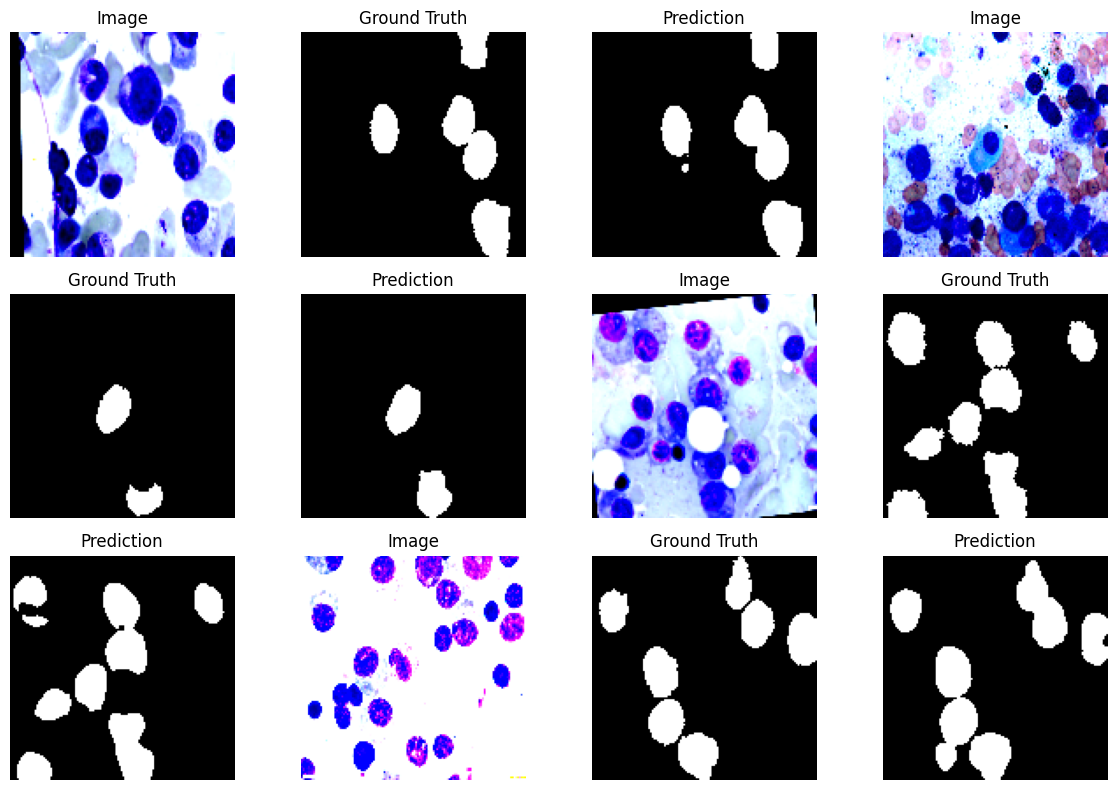

In [1]:
# [1] Imports and Configuration
import os, glob, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score, f1_score

# Config
IMAGE_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x'
MASK_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/y'
BATCH_SIZE = 8
IMAGE_SIZE = 128
NUM_EPOCHS = 50
LR = 4e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

# [3] Dataset
class MyelomaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, '*.bmp')))
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def get_mask_path(self, img_name):
        base = os.path.splitext(os.path.basename(img_name))[0]
        matches = glob.glob(os.path.join(self.mask_dir, f"{base}_*.bmp"))
        masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in matches]
        if not masks:
            return None
        combined = np.clip(np.sum(masks, axis=0), 0, 255).astype(np.uint8)
        _, binary_mask = cv2.threshold(combined, 10, 255, cv2.THRESH_BINARY)
        return binary_mask

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.get_mask_path(img_path)
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float() / 255.0

        return image, mask


# [4] DataLoader
dataset = MyelomaDataset(IMAGE_DIR, MASK_DIR, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# [5] Model
model = smp.UnetPlusPlus(encoder_name="efficientnet-b5",encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)

# [6] Loss and Optimizer
bce = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
criterion = lambda pred, target: bce(pred, target) + dice_loss(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# [7] Training
model.train()
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training")
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": epoch_loss / (pbar.n + 1)})

# [8] Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    iou_scores, f1_scores, dice_scores = [], [], []
    valid_samples = 0
    empty_skips = 0
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Evaluating")
        for images, masks in pbar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(images))
            preds = (outputs > 0.5).float()
            for pred, mask in zip(preds, masks):
                pred_np = pred.squeeze().cpu().numpy().astype(np.uint8)
                mask_np = mask.squeeze().cpu().numpy().astype(np.uint8)

                if mask_np.sum() + pred_np.sum() == 0:
                    empty_skips += 1
                    continue

                valid_samples += 1
                iou_scores.append(jaccard_score(mask_np.flatten(), pred_np.flatten(), zero_division=0))
                f1_scores.append(f1_score(mask_np.flatten(), pred_np.flatten(), zero_division=0))
                intersection = np.logical_and(pred_np, mask_np).sum()
                union = pred_np.sum() + mask_np.sum()
                dice = 2 * intersection / (union + 1e-8)
                dice_scores.append(dice)

    print("\n--- Evaluation Summary ---")
    print(f"Evaluated {valid_samples} valid samples (Skipped {empty_skips})")
    print(f"Mean IoU:  {np.mean(iou_scores) if iou_scores else 'nan'}")
    print(f"Mean F1:   {np.mean(f1_scores) if f1_scores else 'nan'}")
    print(f"Mean Dice: {np.mean(dice_scores) if dice_scores else 'nan'}")

# Run Evaluation
evaluate_model(model, dataloader)

# [9] Visualization
def show_predictions(model, dataloader):
    model.eval()
    samples = iter(dataloader)
    images, masks = next(samples)
    images, masks = images.to(DEVICE), masks.to(DEVICE)
    with torch.no_grad():
        outputs = torch.sigmoid(model(images))
        preds = (outputs > 0.5).float()

    plt.figure(figsize=(12, 8))
    for i in range(min(4, images.shape[0])):
        plt.subplot(3, 4, i*3+1)
        plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
        plt.title("Image")
        plt.axis('off')

        plt.subplot(3, 4, i*3+2)
        plt.imshow(masks[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(3, 4, i*3+3)
        plt.imshow(preds[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, dataloader)

# # [10] Validation Setup
# VAL_IMAGE_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x'
# VAL_MASK_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/y'

# val_dataset = MyelomaDataset(VAL_IMAGE_DIR, VAL_MASK_DIR, transform)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# # [11] Run Evaluation on Validation Set
# print("\nEvaluating on Validation Set:")
# evaluate_model(model, val_loader)

# # [12] Visualize Predictions on Validation Set
# show_predictions(model, val_loader)

Evaluating: 100%|██████████| 38/38 [00:19<00:00,  1.98it/s]


--- Evaluation Summary ---
Evaluated 298 valid samples (Skipped 0)
Mean IoU:  0.8465987445050325
Mean F1:   0.9112340838460636
Mean Dice: 0.9112340838430794


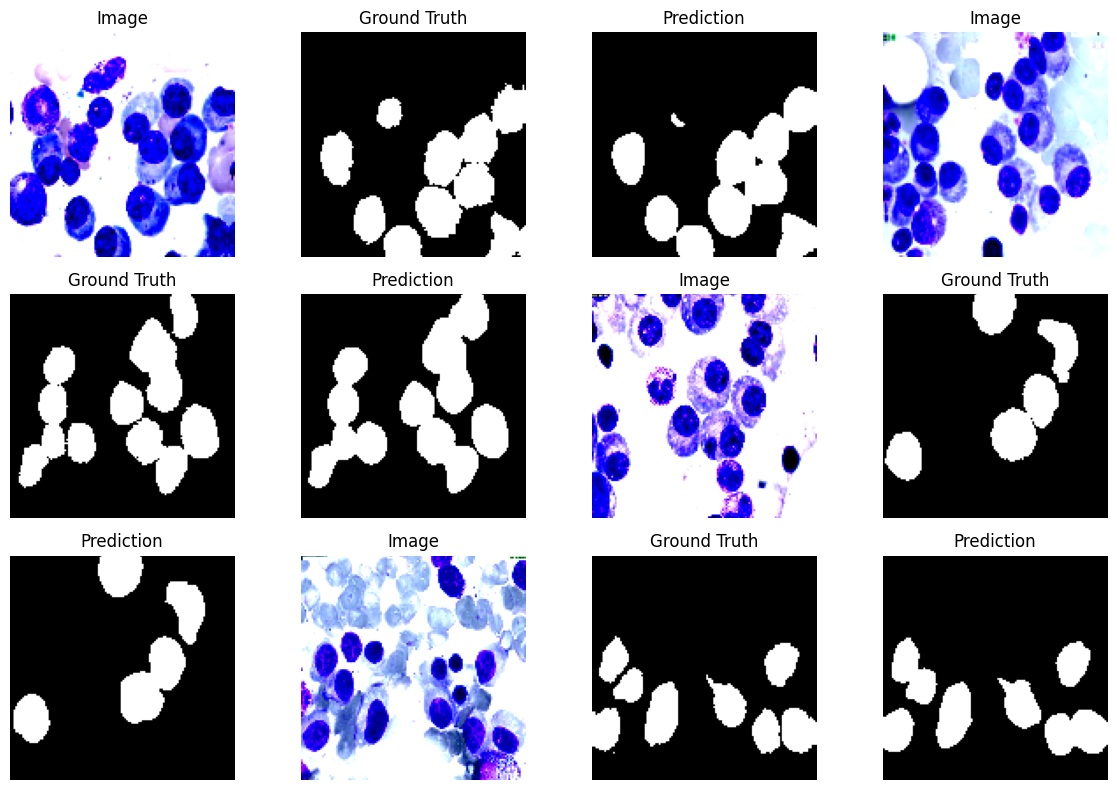


Evaluating on Validation Set:


Evaluating: 100%|██████████| 25/25 [00:38<00:00,  1.54s/it]


--- Evaluation Summary ---
Evaluated 200 valid samples (Skipped 0)
Mean IoU:  0.6652499060452698
Mean F1:   0.7782044429745315
Mean Dice: 0.778204442971964


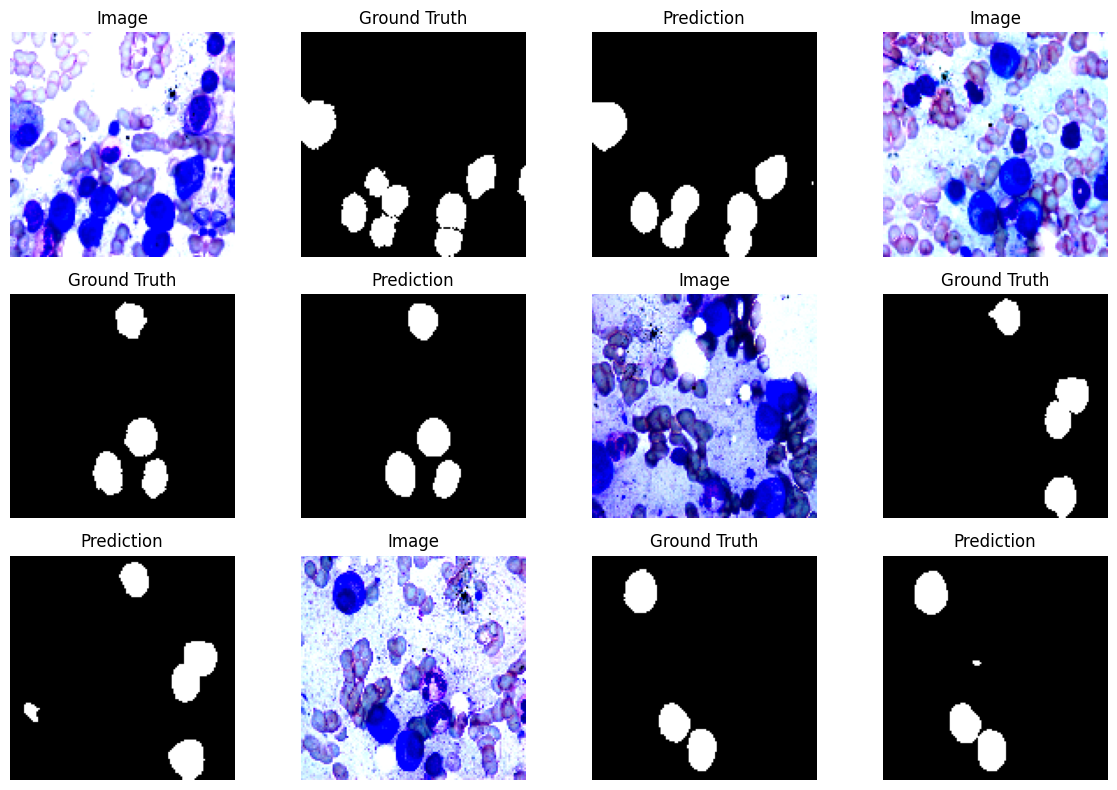

In [1]:
# [1] Imports and Configuration
import os, glob, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score, f1_score

# Config
IMAGE_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x'
MASK_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/y'
BATCH_SIZE = 8
IMAGE_SIZE = 128
NUM_EPOCHS = 50
LR = 4e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

# [3] Dataset
class MyelomaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, '*.bmp')))
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def get_mask_path(self, img_name):
        base = os.path.splitext(os.path.basename(img_name))[0]
        matches = glob.glob(os.path.join(self.mask_dir, f"{base}_*.bmp"))
        masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in matches]
        if not masks:
            return None
        combined = np.clip(np.sum(masks, axis=0), 0, 255).astype(np.uint8)
        _, binary_mask = cv2.threshold(combined, 10, 255, cv2.THRESH_BINARY)
        return binary_mask

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.get_mask_path(img_path)
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float() / 255.0

        return image, mask


# [4] DataLoader
dataset = MyelomaDataset(IMAGE_DIR, MASK_DIR, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# [5] Model
model = smp.UnetPlusPlus(encoder_name="efficientnet-b5",encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)

# [6] Loss and Optimizer
bce = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
criterion = lambda pred, target: bce(pred, target) + dice_loss(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# [7] Training
model.train()
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training")
    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss": epoch_loss / (pbar.n + 1)})

# [8] Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    iou_scores, f1_scores, dice_scores = [], [], []
    valid_samples = 0
    empty_skips = 0
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Evaluating")
        for images, masks in pbar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = torch.sigmoid(model(images))
            preds = (outputs > 0.5).float()
            for pred, mask in zip(preds, masks):
                pred_np = pred.squeeze().cpu().numpy().astype(np.uint8)
                mask_np = mask.squeeze().cpu().numpy().astype(np.uint8)

                if mask_np.sum() + pred_np.sum() == 0:
                    empty_skips += 1
                    continue

                valid_samples += 1
                iou_scores.append(jaccard_score(mask_np.flatten(), pred_np.flatten(), zero_division=0))
                f1_scores.append(f1_score(mask_np.flatten(), pred_np.flatten(), zero_division=0))
                intersection = np.logical_and(pred_np, mask_np).sum()
                union = pred_np.sum() + mask_np.sum()
                dice = 2 * intersection / (union + 1e-8)
                dice_scores.append(dice)

    print("\n--- Evaluation Summary ---")
    print(f"Evaluated {valid_samples} valid samples (Skipped {empty_skips})")
    print(f"Mean IoU:  {np.mean(iou_scores) if iou_scores else 'nan'}")
    print(f"Mean F1:   {np.mean(f1_scores) if f1_scores else 'nan'}")
    print(f"Mean Dice: {np.mean(dice_scores) if dice_scores else 'nan'}")

# Run Evaluation
evaluate_model(model, dataloader)

# [9] Visualization
def show_predictions(model, dataloader):
    model.eval()
    samples = iter(dataloader)
    images, masks = next(samples)
    images, masks = images.to(DEVICE), masks.to(DEVICE)
    with torch.no_grad():
        outputs = torch.sigmoid(model(images))
        preds = (outputs > 0.5).float()

    plt.figure(figsize=(12, 8))
    for i in range(min(4, images.shape[0])):
        plt.subplot(3, 4, i*3+1)
        plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
        plt.title("Image")
        plt.axis('off')

        plt.subplot(3, 4, i*3+2)
        plt.imshow(masks[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(3, 4, i*3+3)
        plt.imshow(preds[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, dataloader)

# # [10] Validation Setup
VAL_IMAGE_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x'
VAL_MASK_DIR = '/kaggle/input/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/y'

val_dataset = MyelomaDataset(VAL_IMAGE_DIR, VAL_MASK_DIR, transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# [11] Run Evaluation on Validation Set
print("\nEvaluating on Validation Set:")
evaluate_model(model, val_loader)

# [12] Visualize Predictions on Validation Set
show_predictions(model, val_loader)